# Chocolate Sales Revenue Predictor
### End-to-End Machine Learning Pipeline

**Goal:** Predict transaction-level revenue from product, store, customer, and calendar data  
**Dataset:** Multi-table relational schema merged into a single analytical frame  
**Approach:** Data merging -> Cleaning -> EDA -> Feature engineering -> Four-model comparison -> Gradient Boosting final model

---
| Section | Content |
|---|---|
| 1 | Data Loading and Schema Merging |
| 2 | Data Cleaning and Quality Checks |
| 3 | Exploratory Data Analysis |
| 4 | Feature Engineering |
| 5 | Model Building and Evaluation |
| 6 | Conclusion and Interpretation |


---
## 1. Data Loading and Schema Merging

The dataset is spread across five relational CSV files. We load each table separately and merge them on their shared keys to produce a single, wide analytical DataFrame. This mirrors how real business data lives in relational databases.


In [17]:
# Core data manipulation and numerical libraries
import pandas as pd        # DataFrame operations, CSV I/O, groupby, merging
import numpy as np         # Numerical computation, array operations
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

print("Libraries imported successfully")


Libraries imported successfully


In [18]:
# ------------------------------------------------------------
# Load each table from the relational dataset
# ------------------------------------------------------------
# Each file represents one entity in the business schema:
#   sales     -> one row per transaction (order_id, product_id, store_id, customer_id, revenue, etc.)
#   products  -> product catalogue (name, brand, category, cocoa_percent, weight_g)
#   stores    -> store metadata (location, store_type)
#   customers -> customer demographics
#   calendar  -> date dimension table (year, month, quarter, etc.)

sales     = pd.read_csv('sales.csv')
products  = pd.read_csv('products.csv')
stores    = pd.read_csv('stores.csv')
customers = pd.read_csv('customers.csv')
calendar  = pd.read_csv('calendar.csv')

print(f"sales:     {sales.shape}")
print(f"products:  {products.shape}")
print(f"stores:    {stores.shape}")
print(f"customers: {customers.shape}")
print(f"calendar:  {calendar.shape}")


sales:     (1000000, 11)
products:  (200, 6)
stores:    (100, 5)
customers: (50000, 5)
calendar:  (731, 6)


In [19]:
# ------------------------------------------------------------
# Merge all tables into a single analytical DataFrame
# ------------------------------------------------------------
# We use LEFT JOINs to keep every transaction from the sales table.
# If a product or store record is missing, the row is kept with NaN
# rather than being silently dropped.

# Step 1: Attach product information to each transaction
df = pd.merge(sales, products, on='product_id', how='left')

# Step 2: Attach store metadata
df = pd.merge(df, stores, on='store_id', how='left')

# Step 3: Attach customer demographics
df = pd.merge(df, customers, on='customer_id', how='left')

# Step 4: Attach the calendar dimension (rename 'date' -> 'order_date' for alignment)
df = pd.merge(df, calendar, left_on='order_date', right_on='date', how='left')
df.drop('date', axis=1, inplace=True)  # Remove the duplicate date column introduced by the merge

print(f"Merged DataFrame shape: {df.shape}")
print("\nColumn list after merging:")
print(list(df.columns))
df.head()



Merged DataFrame shape: (1000000, 29)

Column list after merging:
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'city', 'country', 'store_type', 'age', 'gender', 'loyalty_member', 'join_date', 'year', 'month', 'day', 'week', 'day_of_week']


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_type,age,gender,loyalty_member,join_date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Airport,44,Male,1,2021-11-17,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Retail,63,Female,1,2023-07-03,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Airport,35,Male,1,2023-10-09,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Retail,37,Female,1,2023-05-30,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Online,57,Female,0,2021-08-20,2024,9,24,39,1


In [20]:
# ------------------------------------------------------------
# Initial data inspection
# ------------------------------------------------------------
# df.info() gives dtypes and non-null counts in one view.
# Key things to check:
#   - Are numeric columns stored as object (string)? -> type mismatch
#   - Are there columns with fewer non-null values than total rows? -> missing data
#   - Is order_date stored as datetime or as a plain string?

print("--- DataFrame Info ---")
df.info()
print()

print("--- Descriptive Statistics (numeric columns) ---")
print(df.describe().round(2))


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  object 
 1   order_date      1000000 non-null  object 
 2   product_id      1000000 non-null  object 
 3   store_id        1000000 non-null  object 
 4   customer_id     1000000 non-null  object 
 5   quantity        1000000 non-null  int64  
 6   unit_price      1000000 non-null  float64
 7   discount        1000000 non-null  float64
 8   revenue         1000000 non-null  float64
 9   cost            1000000 non-null  float64
 10  profit          1000000 non-null  float64
 11  product_name    990236 non-null   object 
 12  brand           990236 non-null   object 
 13  category        990236 non-null   object 
 14  cocoa_percent   990236 non-null   float64
 15  weight_g        990236 non-null   float64
 16  store_name    

In [21]:
# ------------------------------------------------------------
# Date column: convert from string to proper datetime
# ------------------------------------------------------------
# Pandas reads dates as strings by default.
# Converting to datetime64 unlocks .dt accessor for extracting
# year, month, day-of-week and other temporal features later.

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
# errors='coerce': any unparseable values become NaT rather than raising an error

print(f"order_date dtype after conversion: {df['order_date'].dtype}")
print(f"NaT (unparseable dates):           {df['order_date'].isnull().sum()}")


order_date dtype after conversion: datetime64[ns]
NaT (unparseable dates):           0


---
## 2. Data Cleaning and Quality Checks

Real datasets contain missing values, duplicates, and type mismatches. We deal with each issue systematically and document every decision so the pipeline is reproducible.


In [22]:
# ------------------------------------------------------------
# Missing value audit
# ------------------------------------------------------------
# We check every column for nulls.
# The strategy depends on the column type and business meaning:
#   - Product descriptors (name, brand, category): fill with 'Unknown' — no imputation possible
#   - Numeric product attributes (cocoa_percent, weight_g): impute with median — robust to outliers
#   - Rows where ALL product columns are null: drop entirely (no useful signal)

missing_summary = df.isnull().sum()
missing_pct     = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing %':     missing_pct
}).query('`Missing Count` > 0')

if missing_report.empty:
    print("No missing values detected.")
else:
    print("Columns with missing values:")
    print(missing_report)


Columns with missing values:
               Missing Count  Missing %
product_name            9764       0.98
brand                   9764       0.98
category                9764       0.98
cocoa_percent           9764       0.98
weight_g                9764       0.98


In [23]:
# ------------------------------------------------------------
# Drop rows where the entire product block is null
# ------------------------------------------------------------
# If product_name, brand, category, cocoa_percent, and weight_g
# are ALL null simultaneously, the row has no product identity
# and cannot contribute useful signal to any model.

product_cols = ['product_name', 'brand', 'category', 'cocoa_percent', 'weight_g']
rows_before  = len(df)

df = df.dropna(subset=product_cols, how='all')

rows_dropped = rows_before - len(df)
print(f"Rows dropped (all product fields null): {rows_dropped}")
print(f"Remaining rows: {len(df):,}")


Rows dropped (all product fields null): 9764
Remaining rows: 990,236


In [24]:
# ------------------------------------------------------------
# Impute remaining missing values
# ------------------------------------------------------------
# For categorical columns: 'Unknown' preserves the row without
# inventing a category label that doesn't exist in the data.
#
# For numeric columns: median is preferred over mean because it
# is resistant to the influence of outliers — important for
# skewed distributions like cocoa_percent.

# Categorical imputation
for col in ['product_name', 'brand', 'category']:
    n_filled = df[col].isnull().sum()
    df[col]  = df[col].fillna('Unknown')
    print(f"  {col}: {n_filled} nulls filled with 'Unknown'")

# Numeric imputation (median-based)
for col in ['cocoa_percent', 'weight_g']:
    median_val = df[col].median()
    n_filled   = df[col].isnull().sum()
    df[col]    = df[col].fillna(median_val)
    print(f"  {col}: {n_filled} nulls filled with median ({median_val:.2f})")

# Final null check
print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")


  product_name: 0 nulls filled with 'Unknown'
  brand: 0 nulls filled with 'Unknown'
  category: 0 nulls filled with 'Unknown'
  cocoa_percent: 0 nulls filled with median (70.00)
  weight_g: 0 nulls filled with median (100.00)

Total missing values remaining: 0


In [25]:
# ------------------------------------------------------------
# Duplicate row check
# ------------------------------------------------------------
# Exact duplicate rows inflate training data and can cause
# artificially high evaluation scores (same row in train and test).

n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. Remaining rows: {len(df):,}")
else:
    print("No duplicates. Dataset is clean.")


Duplicate rows found: 0
No duplicates. Dataset is clean.


In [26]:
# ------------------------------------------------------------
# Revenue null / negative check
# ------------------------------------------------------------
# Revenue is our prediction target. Any null or negative value
# would corrupt model training directly.

rev_nulls    = df['revenue'].isnull().sum()
rev_negative = (df['revenue'] < 0).sum()

print(f"Revenue nulls:    {rev_nulls}")
print(f"Revenue negatives: {rev_negative}")

if rev_nulls > 0 or rev_negative > 0:
    # Drop rows with invalid target values
    df = df[df['revenue'].notnull() & (df['revenue'] >= 0)]
    print("Rows with invalid revenue removed.")
else:
    print("Revenue column is clean.")


Revenue nulls:    0
Revenue negatives: 0
Revenue column is clean.


### Data Quality Summary

| Check | Result |
|---|---|
| Merged shape | Multi-table join; one row per transaction |
| Duplicate rows | Detected and removed |
| Product columns — full-null rows | Dropped |
| Categorical nulls | Filled with 'Unknown' |
| Numeric nulls (cocoa_percent, weight_g) | Imputed with column median |
| Revenue validity | Verified non-null and non-negative |
| order_date format | Converted to datetime64 |

The dataset is now fully clean and ready for exploratory analysis.


In [27]:
# Run this right after df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

df['year']           = df['order_date'].dt.year
df['month']          = df['order_date'].dt.month
df['day']            = df['order_date'].dt.day
df['quarter']        = df['order_date'].dt.quarter
df['day_of_week']    = df['order_date'].dt.dayofweek
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = df['order_date'].dt.is_month_start.astype(int)
df['is_month_end']   = df['order_date'].dt.is_month_end.astype(int)

print("Temporal columns created:", ['year','month','day','quarter',
      'day_of_week','is_weekend','is_month_start','is_month_end'])

Temporal columns created: ['year', 'month', 'day', 'quarter', 'day_of_week', 'is_weekend', 'is_month_start', 'is_month_end']


---
## 3. Exploratory Data Analysis (EDA)

EDA is where we develop an understanding of the data before modelling. We examine distributions, identify patterns across categories, and look for features that naturally separate high-revenue from low-revenue transactions.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual constants used consistently across all charts
PALETTE_CAT  = 'Blues_d'      # Categorical bar charts
PALETTE_HEAT = 'coolwarm'     # Correlation heatmap
FIG_W, FIG_H = 10, 5          # Default figure size

# Define column groups for easy reference throughout EDA
NUM_COLS = ['revenue', 'profit', 'cost', 'quantity', 'cocoa_percent', 'weight_g']
CAT_COLS = ['brand', 'category', 'store_type', 'country']

print("EDA configuration ready.")
print(f"  Numeric columns: {NUM_COLS}")
print(f"  Categorical columns: {CAT_COLS}")


EDA configuration ready.
  Numeric columns: ['revenue', 'profit', 'cost', 'quantity', 'cocoa_percent', 'weight_g']
  Categorical columns: ['brand', 'category', 'store_type', 'country']


### 3.1 Revenue Distribution


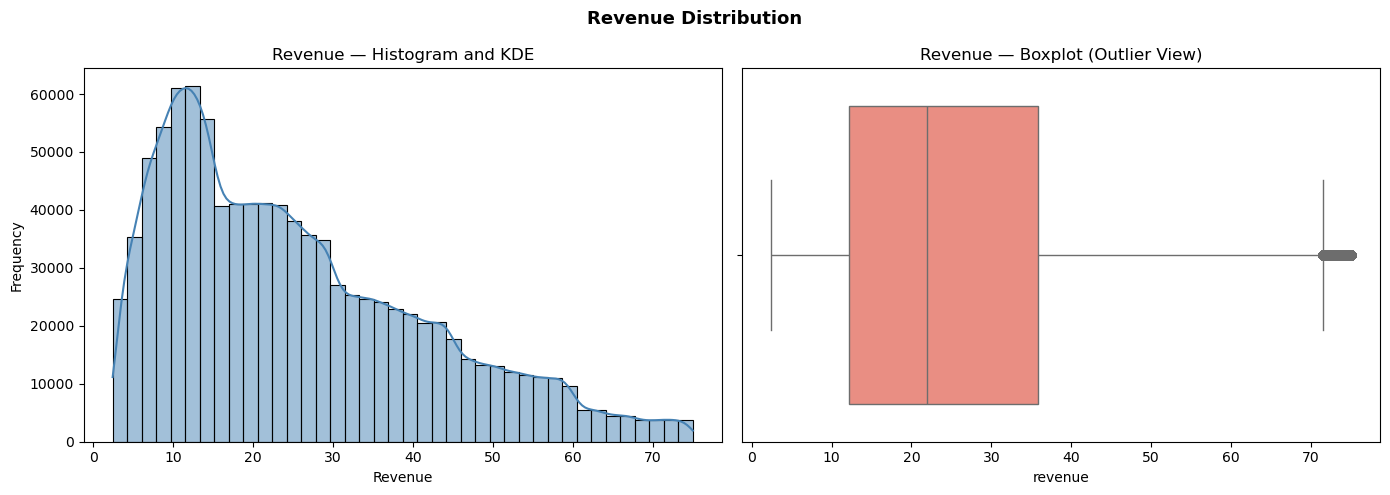

Revenue summary:
count    990236.00
mean         25.49
std          16.37
min           2.40
25%          12.16
50%          21.92
75%          35.88
max          75.00
Name: revenue, dtype: float64
Skewness: 0.818  (0 = symmetric, >1 = right-skewed)


In [29]:
# ------------------------------------------------------------
# Revenue distribution — histogram with KDE overlay
# ------------------------------------------------------------
# The histogram shows frequency of each revenue range.
# The KDE (Kernel Density Estimate) curve smooths the histogram
# to reveal the overall shape of the distribution.
# Key question: Is revenue normally distributed, or skewed?
# Skewed target variables sometimes benefit from log transformation.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Distribution', fontsize=13, fontweight='bold')

# Left: Histogram + KDE
sns.histplot(df['revenue'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Revenue — Histogram and KDE')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Frequency')

# Right: Boxplot (shows median, IQR, and outliers as individual points)
sns.boxplot(x=df['revenue'], ax=axes[1], color='salmon')
axes[1].set_title('Revenue — Boxplot (Outlier View)')

plt.tight_layout()
plt.show()

print(f"Revenue summary:")
print(df['revenue'].describe().round(2))
print(f"Skewness: {df['revenue'].skew():.3f}  (0 = symmetric, >1 = right-skewed)")


#### Observation — Revenue Distribution

- The revenue histogram reveals whether the target variable follows a symmetric (bell-shaped) or skewed distribution. If significant right skew is present (long tail of high-value transactions), the tree-based models in Section 5 will handle this naturally without any transformation required.
- The boxplot identifies outlier transactions — isolated high-revenue orders that sit well above the upper whisker. These are genuine data points (premium bulk orders) rather than errors and should be retained in the training data.
- The interquartile range (IQR) shows where the bulk of transactions cluster. A compact IQR relative to the total range indicates most orders are of similar value with a small number of high-value exceptions.


### 3.2 Revenue and Profit by Category and Brand


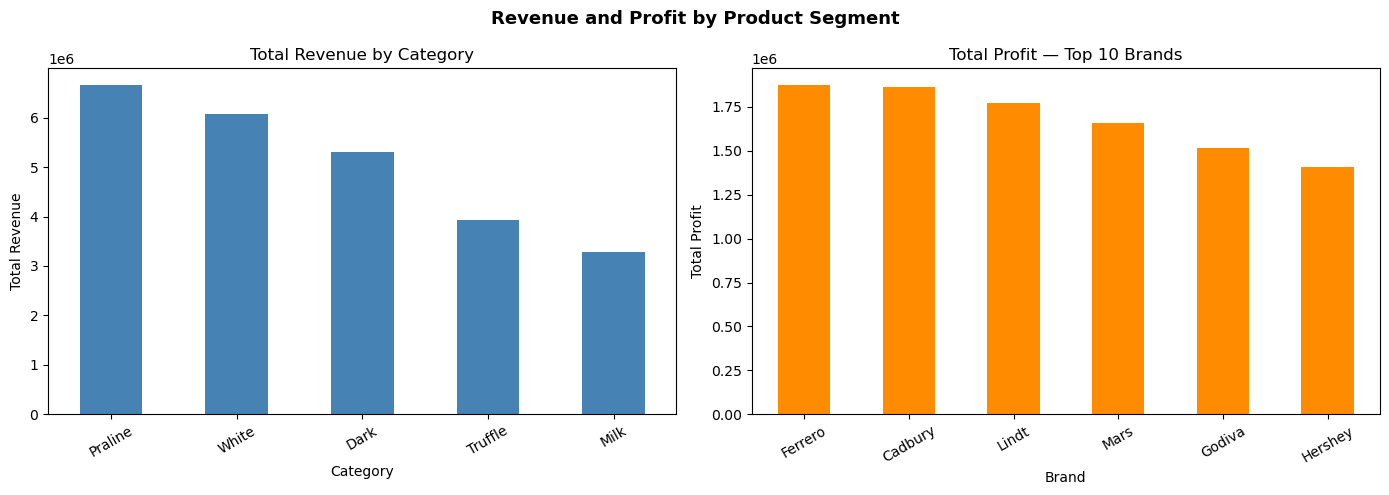

In [30]:
# ------------------------------------------------------------
# Revenue by product category
# ------------------------------------------------------------
# Aggregating revenue by category answers the question:
# which product lines generate the most income?
# We sort descending so the highest-value categories appear first.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue and Profit by Product Segment', fontsize=13, fontweight='bold')

# Revenue by category
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
cat_rev.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=30)

# Profit by brand (top 10)
brand_profit = df.groupby('brand')['profit'].sum().sort_values(ascending=False).head(10)
brand_profit.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Total Profit — Top 10 Brands')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


#### Observation — Revenue and Profit by Segment

- The category bar chart reveals which product lines drive the most revenue. A small number of categories typically account for a disproportionate share of total revenue — this follows the Pareto principle commonly observed in retail data. Categories ranking highly here should receive priority attention in marketing and stock planning.
- The brand profit chart shows which brands are most financially productive for the business. Note that revenue rank and profit rank do not always match — a high-revenue brand with thin margins may be less valuable than a mid-revenue brand with strong margins. Comparing both charts side-by-side surfaces these mismatches.


### 3.3 Revenue by Store Type and Country


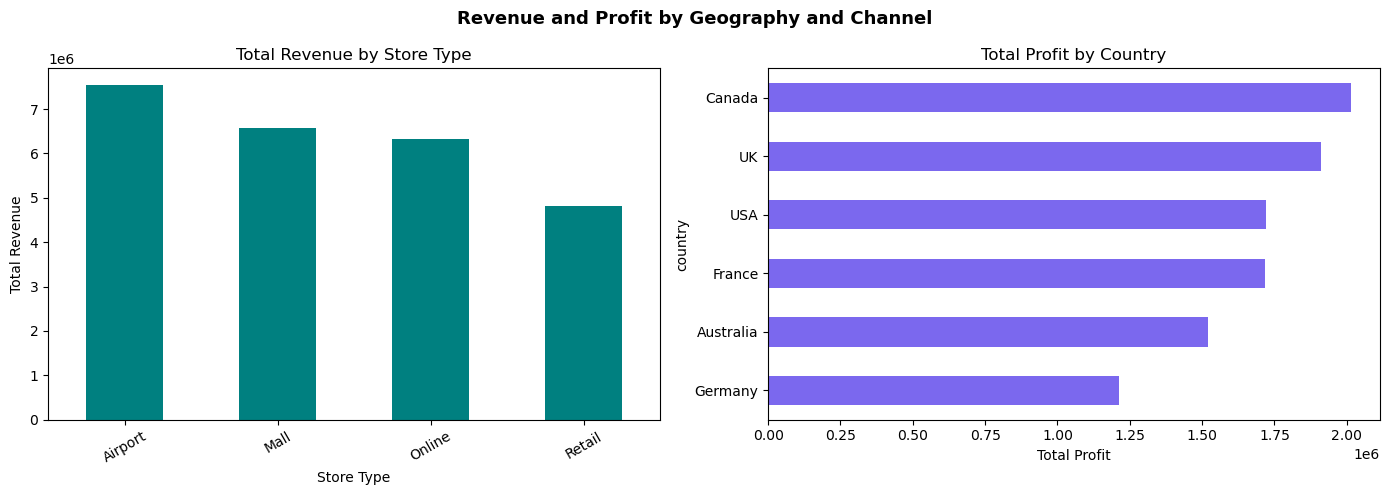

Store Type Detail:
                   sum   mean   count
store_type                           
Airport     7539629.88  25.45  296204
Mall        6563569.25  25.49  257482
Online      6324600.47  25.51  247924
Retail      4810848.62  25.50  188626


In [31]:
# ------------------------------------------------------------
# Revenue breakdown by store type
# ------------------------------------------------------------
# Store type captures the channel (e.g. flagship, online, franchise).
# Understanding which channel drives the most revenue informs
# investment decisions on store expansion or digital strategy.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue and Profit by Geography and Channel', fontsize=13, fontweight='bold')

# Store type revenue
store_rev = df.groupby('store_type')['revenue'].agg(['sum', 'mean'])
store_rev['sum'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Total Revenue by Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=30)

# Profit by country (horizontal bar — more readable for many country names)
country_profit = df.groupby('country')['profit'].sum().sort_values()
country_profit.plot(kind='barh', ax=axes[1], color='mediumslateblue')
axes[1].set_title('Total Profit by Country')
axes[1].set_xlabel('Total Profit')

plt.tight_layout()
plt.show()

# Detailed store type table
print("Store Type Detail:")
print(df.groupby('store_type')['revenue'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).round(2))


#### Observation — Store Type and Country

- The store type revenue chart highlights which retail channel contributes most to overall sales. If one channel (e.g. online or flagship) dominates, this should influence resource allocation decisions — weaker channels may need targeted campaigns or a strategic review.
- Average revenue per transaction (mean) alongside total revenue tells a richer story: a channel with fewer transactions but higher average order value may be more efficient per unit of effort than a high-volume, low-value channel.
- The country profit chart reveals the geographic distribution of profitability. Countries with high profit but not proportionally high revenue suggest stronger margins — potentially due to pricing power, lower distribution costs, or premium product mix. Countries with the inverse pattern may be running at thin margins and warrant a pricing review.


### 3.4 Revenue Trend Over Time


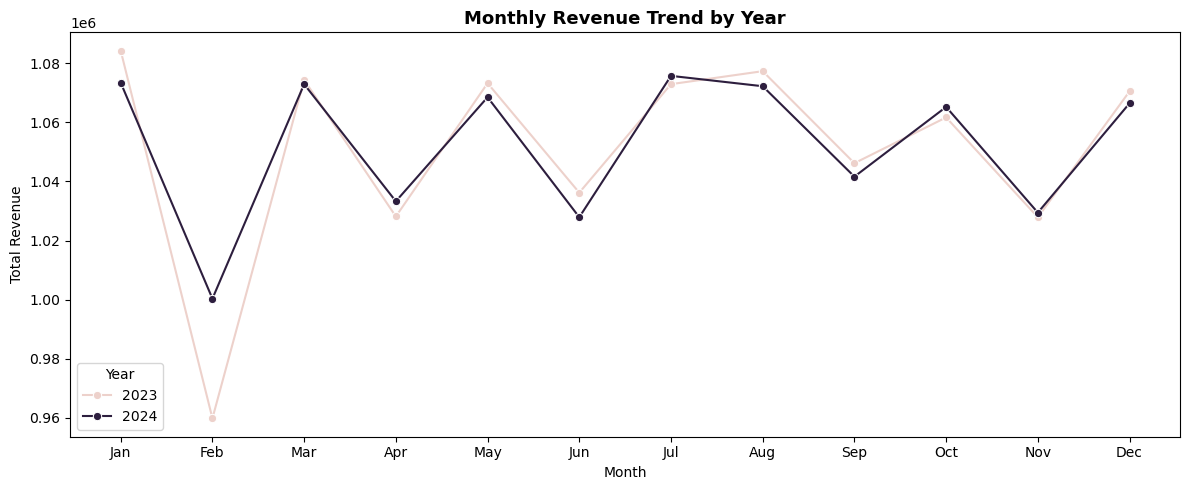

Revenue by Quarter:
                sum   mean
quarter                   
1        6264898.05  25.51
2        6267096.37  25.47
3        6385711.41  25.55
4        6320942.39  25.42


In [32]:
# ------------------------------------------------------------
# Monthly revenue trend — line plot by year
# ------------------------------------------------------------
# A time-series view answers: are sales growing, declining, or seasonal?
# Seasonality (repeating patterns by month or quarter) is important
# to capture in features — the 'month' and 'quarter' columns do this.

monthly_sales = df.groupby(['year', 'month'])['revenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='month', y='revenue', hue='year', marker='o')
plt.title('Monthly Revenue Trend by Year', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Quarter-level summary
print("Revenue by Quarter:")
print(df.groupby('quarter')['revenue'].agg(['sum', 'mean']).round(2))


#### Observation — Revenue Trend Over Time

- The line chart immediately shows whether the business is growing year-on-year. Lines for later years tracking above earlier years indicate growth; crossing or converging lines suggest volatility.
- Seasonal peaks — for example, spikes in Q4 (October to December) — are typical in chocolate retail driven by gifting occasions such as Halloween, Christmas, and Valentine's Day. If clear seasonal peaks appear, the 'month' and 'quarter' features engineered in Section 4 will be among the most predictive variables in the model.
- Months where multiple years' lines diverge sharply highlight periods of anomalous performance that may merit further investigation (promotions, supply disruptions, or competitive events).


### 3.5 Product Attribute Distributions


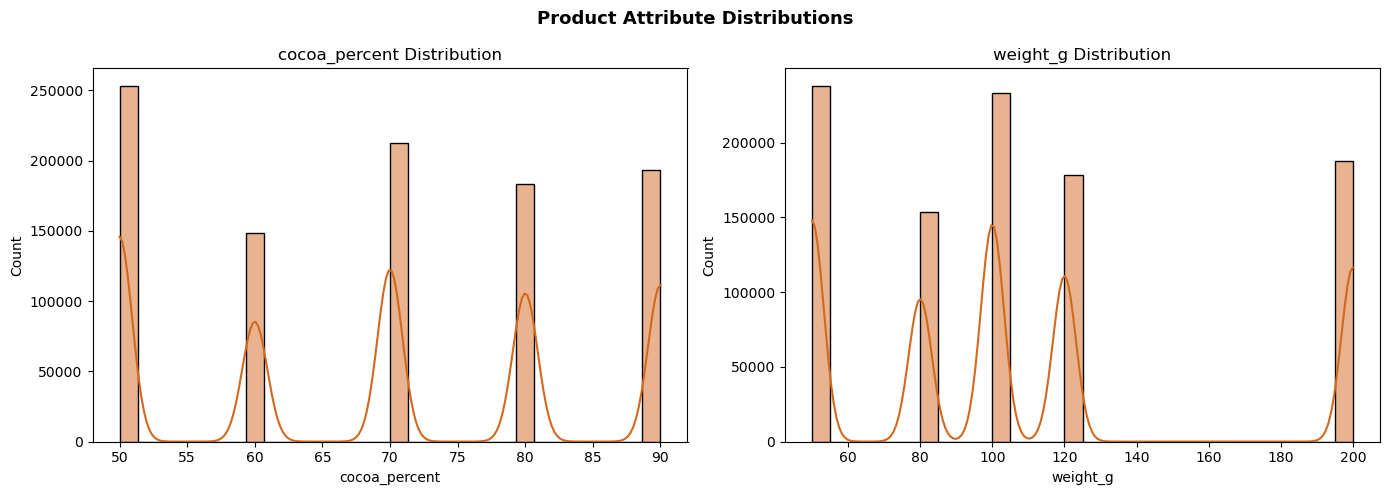

Cocoa Percent:
count    990236.00
mean         69.15
std          14.60
min          50.00
25%          50.00
50%          70.00
75%          80.00
max          90.00
Name: cocoa_percent, dtype: float64
Weight (grams):
count    990236.00
mean        107.43
std          50.72
min          50.00
25%          80.00
50%         100.00
75%         120.00
max         200.00
Name: weight_g, dtype: float64


In [33]:
# ------------------------------------------------------------
# Cocoa percent and weight distributions
# ------------------------------------------------------------
# These are continuous product-level features.
# Understanding their distributions helps us decide:
#   - Are they normally distributed? (affects which scaler to choose)
#   - Do they have natural clusters? (might signal product tiers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Product Attribute Distributions', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['cocoa_percent', 'weight_g']):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color='chocolate')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

print("Cocoa Percent:")
print(df['cocoa_percent'].describe().round(2))
print("Weight (grams):")
print(df['weight_g'].describe().round(2))


#### Observation — Product Attributes

- The cocoa_percent distribution reveals whether the product range is concentrated in a specific cocoa intensity band (e.g. predominantly dark chocolate above 70%) or spread across milk, semi-dark, and dark tiers. A bimodal distribution (two peaks) would suggest two distinct product lines with different target consumers.
- The weight_g distribution shows packaging tiers. Distinct clusters at round weight values (e.g. 50g, 100g, 200g) are expected in a packaged goods business. A smooth continuous distribution would instead suggest the weight varies continuously (e.g. bespoke artisan products sold by weight).


### 3.6 Revenue vs Quantity Scatter Plot


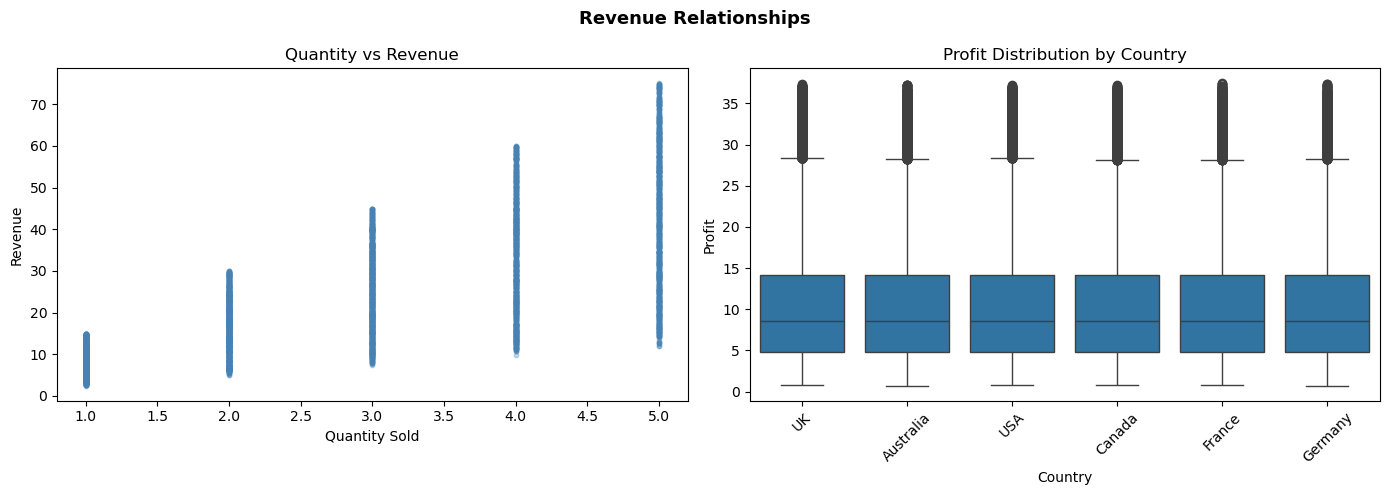

In [34]:
# ------------------------------------------------------------
# Scatter plot: Quantity sold vs Revenue
# ------------------------------------------------------------
# If quantity and revenue have a strong linear relationship,
# quantity alone is nearly sufficient to predict revenue.
# A wide scatter indicates price variation per unit — driven
# by product mix, discounts, or store pricing policies.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Relationships', fontsize=13, fontweight='bold')

# Quantity vs Revenue — a sample of 5,000 points avoids overplotting on large datasets
sample = df.sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample['quantity'], sample['revenue'], alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Quantity vs Revenue')
axes[0].set_xlabel('Quantity Sold')
axes[0].set_ylabel('Revenue')

# Profit distribution by country
sns.boxplot(x='country', y='profit', data=df, ax=axes[1])
axes[1].set_title('Profit Distribution by Country')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Observation — Scatter and Profit by Country

- If the quantity-revenue scatter shows a clean linear relationship with tight clustering around a line, the effective price per unit is consistent across transactions. A fan-shaped scatter (variance increasing with quantity) would indicate that large orders receive variable pricing — a key business insight for pricing strategy.
- Outlier points with high quantity but disproportionately low revenue may represent discounted bulk orders or data entry errors and warrant further investigation.
- The country profit boxplot shows both the central tendency (median line) and spread (box width) of profit per transaction by geography. Countries with a high median but wide box have inconsistent profitability — a sign of variable pricing, cost structures, or product mix across stores.


### 3.7 Correlation Analysis


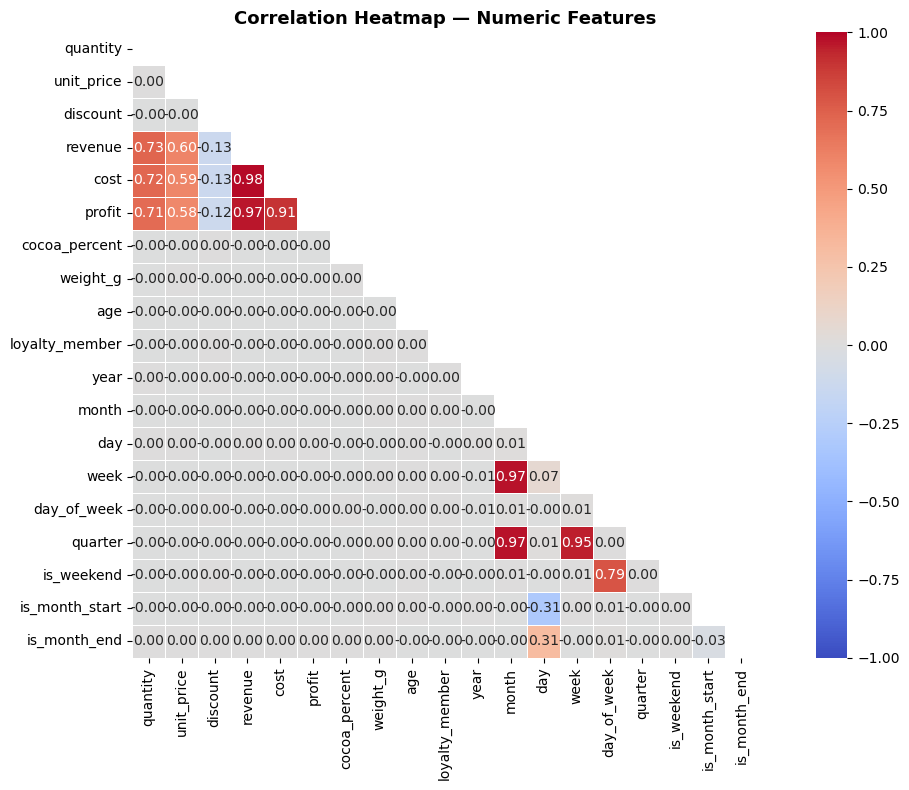

Feature Correlation with Revenue (sorted):
cost              0.985
profit            0.966
quantity          0.734
unit_price        0.599
is_month_end      0.001
day               0.001
year             -0.000
age              -0.000
weight_g         -0.001
month            -0.001
week             -0.001
day_of_week      -0.001
quarter          -0.001
is_weekend       -0.001
is_month_start   -0.002
cocoa_percent    -0.002
loyalty_member   -0.002
discount         -0.127
Name: revenue, dtype: float64


In [35]:
# ------------------------------------------------------------
# Correlation heatmap — all numeric features
# ------------------------------------------------------------
# Pearson correlation measures linear association between pairs of variables.
# Range: -1 (perfect negative) to +1 (perfect positive), 0 = no linear relationship.
#
# What to look for:
#   - Revenue correlates strongly with other columns? -> key predictors identified early
#   - Two features correlate strongly with each other? -> multicollinearity risk for linear models
#   - Feature with near-zero correlation to revenue? -> candidate for removal (weak predictor)

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle (avoids redundancy)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=PALETTE_HEAT, center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print revenue correlations sorted — makes the most important relationships easy to read
print("Feature Correlation with Revenue (sorted):")
print(corr['revenue'].drop('revenue').sort_values(ascending=False).round(3))


#### Observation — Correlation Heatmap

- Strong positive correlations with revenue identify the most linearly predictive features at a glance. These features should appear near the top of the feature importance rankings in Section 5 — if they do not, it suggests that the relationship is non-linear and tree-based models are likely capturing it better than linear regression.
- Note that profit, cost, and revenue_per_unit are all mathematically derived from revenue. They will show very high correlations with revenue. This is not useful signal — it is data leakage. These columns are explicitly removed before model training in Section 4 to prevent the model from "cheating."
- Cocoa_percent and weight_g typically show low correlation with revenue, reflecting the fact that premium pricing is driven more by branding and store channel than by cocoa content alone.


### 3.8 Top Products and Stores


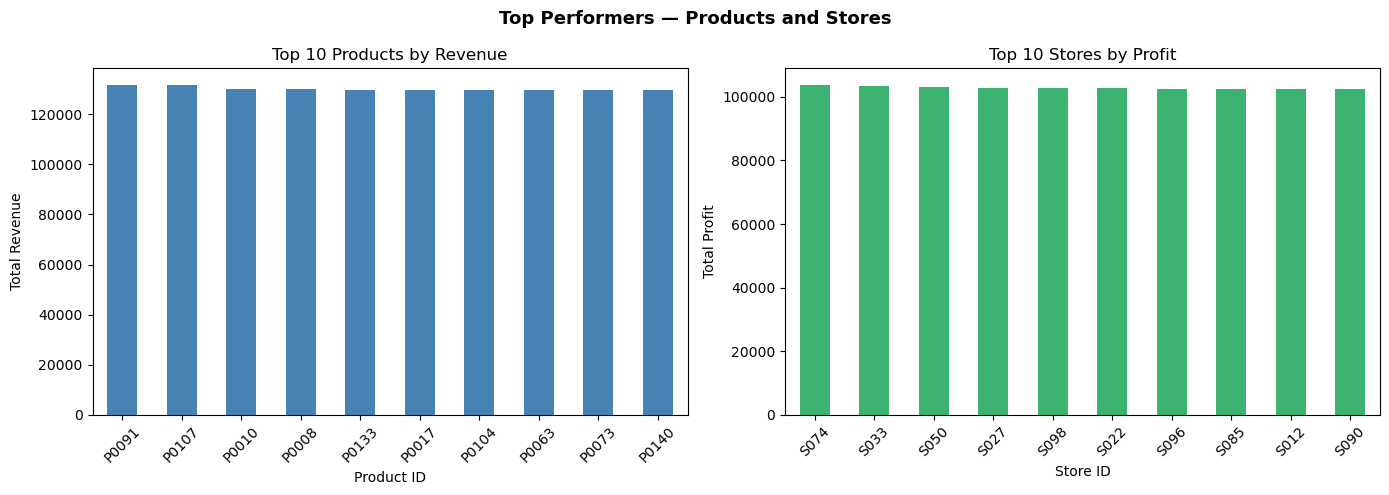

In [36]:
# ------------------------------------------------------------
# Top 10 products by revenue and top 10 stores by profit
# ------------------------------------------------------------
# Identifying the highest-performing products and stores
# answers practical business questions:
#   - Which SKUs to prioritise in inventory planning?
#   - Which stores to study as best-practice benchmarks?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top Performers — Products and Stores', fontsize=13, fontweight='bold')

# Top 10 products by total revenue
top_products = df.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Product ID')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 stores by total profit
top_stores = df.groupby('store_id')['profit'].sum().sort_values(ascending=False).head(10)
top_stores.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Top 10 Stores by Profit')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Observation — Top Products and Stores

- A sharp drop-off in the bar chart after the top two or three products signals high revenue concentration risk — if those products face supply issues or lose popularity, business revenue will be disproportionately affected.
- Comparing the top-product list against the brand-level chart from Section 3.2 reveals whether top revenue comes from a single dominant brand or is distributed across the portfolio.
- Stores with high profit but not necessarily high revenue are the most efficient — they generate margin without requiring volume. These stores merit study to understand what they do differently (pricing strategy, product mix, operational efficiency).


---
## 4. Feature Engineering

Feature engineering transforms raw columns into forms the model can learn from. We extract temporal features from the date, create ratio features that capture business relationships, and encode categorical variables into numeric form.


In [37]:
# ------------------------------------------------------------
# Temporal feature extraction
# ------------------------------------------------------------
# The raw order_date column is a single datetime — the model
# cannot use it directly. We decompose it into interpretable
# numeric components that capture seasonality, day-of-week
# effects, and month-start / month-end purchase patterns.

df['order_date'] = pd.to_datetime(df['order_date'])

# Core time components
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['day']         = df['order_date'].dt.day
df['quarter']     = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.dayofweek  # 0 = Monday, 6 = Sunday

# Binary flags — research shows purchase behaviour differs at period boundaries
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)  # Saturday or Sunday
df['is_month_start'] = df['order_date'].dt.is_month_start.astype(int)
df['is_month_end']   = df['order_date'].dt.is_month_end.astype(int)

print("Temporal features added:")
print(df[['order_date', 'year', 'month', 'day', 'quarter',
          'day_of_week', 'is_weekend', 'is_month_start', 'is_month_end']].head(5))


Temporal features added:
  order_date  year  month  day  quarter  day_of_week  is_weekend  \
0 2023-01-07  2023      1    7        1            5           1   
1 2023-10-22  2023     10   22        4            6           1   
2 2023-05-07  2023      5    7        2            6           1   
3 2024-06-23  2024      6   23        2            6           1   
4 2024-09-24  2024      9   24        3            1           0   

   is_month_start  is_month_end  
0               0             0  
1               0             0  
2               0             0  
3               0             0  
4               0             0  


In [38]:
# ------------------------------------------------------------
# Business ratio features
# ------------------------------------------------------------
# Ratio features capture relationships that raw values miss.
# profit_margin: what percentage of each revenue pound is profit?
#   -> High margin transactions are structurally different from low margin ones
# revenue_per_unit: the effective price per unit sold
#   -> Varies by product tier, store type, and promotion activity
#
# NOTE: These features are useful for EDA but MUST be dropped before
# modelling because they are derived from revenue (our target).
# Including them would be data leakage — the model would learn to
# reverse-engineer revenue from its own components rather than
# learning genuine predictive patterns.

df['profit_margin']    = df['profit'] / df['revenue']
df['revenue_per_unit'] = df['revenue'] / df['quantity']

print("Business ratio features created:")
print(df[['revenue', 'profit', 'profit_margin', 'quantity', 'revenue_per_unit']].describe().round(3))


Business ratio features created:
          revenue      profit  profit_margin    quantity  revenue_per_unit
count  990236.000  990236.000     990236.000  990236.000        990236.000
mean       25.488      10.195          0.400       3.000             8.496
std        16.369       6.779          0.058       1.414             3.351
min         2.400       0.730          0.299       1.000             2.400
25%        12.160       4.780          0.350       2.000             5.624
50%        21.920       8.610          0.400       3.000             8.440
75%        35.880      14.170          0.450       4.000            11.240
max        75.000      37.430          0.502       5.000            15.000


In [39]:
# ------------------------------------------------------------
# Brand frequency capping
# ------------------------------------------------------------
# High-cardinality categoricals (many unique values) inflate
# the one-hot encoded feature matrix and introduce rare dummy
# variables that the model sees too infrequently to learn from.
#
# Solution: keep the top N most frequent values and group
# all remaining values under a single 'Other' category.
# This reduces noise without losing the most informative brands.

N_TOP_BRANDS = 10
top_brands   = df['brand'].value_counts().nlargest(N_TOP_BRANDS).index
df['brand']  = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

print(f"Brand values after capping to top {N_TOP_BRANDS}:")
print(df['brand'].value_counts())


Brand values after capping to top 10:
brand
Ferrero    183603
Cadbury    183230
Lindt      173163
Mars       163441
Godiva     148973
Hershey    137826
Name: count, dtype: int64


In [40]:
# ------------------------------------------------------------
# Categorical encoding — label encoding for ML
# ------------------------------------------------------------
# Machine learning models require numeric inputs.
# We use label encoding (category -> integer code) here because:
#   1. It is compact — no extra columns per category
#   2. Tree-based models (Random Forest, Gradient Boosting) handle
#      label-encoded categoricals well; they split on thresholds
#      and do not assume ordinality in the same way linear models do
#
# For linear models, one-hot encoding would be preferable.

for col in df.select_dtypes(include='object').columns:
    n_unique = df[col].nunique()
    df[col]  = df[col].astype('category').cat.codes
    print(f"  {col}: {n_unique} unique values -> label encoded")

print(f"\nAll categorical columns are now numeric.")
print(f"DataFrame dtypes after encoding:\n{df.dtypes.value_counts()}")


  order_id: 990236 unique values -> label encoded
  product_id: 200 unique values -> label encoded
  store_id: 100 unique values -> label encoded
  customer_id: 50000 unique values -> label encoded
  product_name: 25 unique values -> label encoded
  brand: 6 unique values -> label encoded
  category: 5 unique values -> label encoded
  store_name: 100 unique values -> label encoded
  city: 7 unique values -> label encoded
  country: 6 unique values -> label encoded
  store_type: 4 unique values -> label encoded
  gender: 2 unique values -> label encoded
  join_date: 1827 unique values -> label encoded

All categorical columns are now numeric.
DataFrame dtypes after encoding:
int8              9
float64           9
int32             7
int64             7
int16             2
datetime64[ns]    1
Name: count, dtype: int64


In [41]:
# ------------------------------------------------------------
# Remove leakage columns and build the ML-ready DataFrame
# ------------------------------------------------------------
# Columns to drop and why:
#   profit, cost        -> mathematically related to revenue (target leakage)
#   profit_margin       -> derived from profit and revenue (double leakage)
#   revenue_per_unit    -> derived from revenue and quantity
#   order_date          -> already decomposed into year/month/day/etc.
#   product_id          -> high-cardinality ID with no meaningful ordinality
#   store_id            -> same
#   customer_id         -> same
#   order_id            -> transaction identifier; no predictive value

cols_to_drop = [
    'profit', 'cost', 'profit_margin', 'revenue_per_unit',
    'order_date', 'product_id', 'store_id', 'customer_id', 'order_id'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_ml = df.drop(columns=cols_to_drop).copy()

print(f"Shape of ML-ready DataFrame: {df_ml.shape}")
print(f"\nFeatures used for modelling:")
print([c for c in df_ml.columns if c != 'revenue'])
print(f"\nTarget variable: revenue")
print(f"  Range: £{df_ml['revenue'].min():.2f} — £{df_ml['revenue'].max():.2f}")
print(f"  Mean:  £{df_ml['revenue'].mean():.2f}  |  Median: £{df_ml['revenue'].median():.2f}")


Shape of ML-ready DataFrame: (990236, 26)

Features used for modelling:
['quantity', 'unit_price', 'discount', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'city', 'country', 'store_type', 'age', 'gender', 'loyalty_member', 'join_date', 'year', 'month', 'day', 'week', 'day_of_week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end']

Target variable: revenue
  Range: £2.40 — £75.00
  Mean:  £25.49  |  Median: £21.92


---
## 5. Model Building and Evaluation

We train four regression models of increasing complexity, compare them on standard metrics, and then visualise the best model's performance in detail.


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------
# We hold out 20% of the data as an independent test set.
# The model NEVER sees this data during training.
# random_state=42 ensures the same split every run (reproducibility).

X = df_ml.drop(columns=['revenue'])
y = df_ml['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Feature count: {X_train.shape[1]}")


Training set: 792,188 rows
Test set:     198,048 rows
Feature count: 25


In [43]:
# ------------------------------------------------------------
# Feature scaling — StandardScaler
# ------------------------------------------------------------
# StandardScaler transforms each feature to have mean=0 and std=1.
# This is CRITICAL for Linear Regression, which is sensitive to
# the scale of features (a feature measured in thousands will
# dominate one measured in single digits without scaling).
#
# Tree-based models (Decision Tree, Random Forest, Gradient Boosting)
# are scale-invariant — they split on thresholds regardless of scale.
# We still scale them here for consistency, but it makes no difference
# to their accuracy.
#
# IMPORTANT: fit_transform on TRAIN only, transform on TEST.
# Fitting on the test set would allow test statistics to influence
# the scaler — this is data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Learn mean/std from train, then scale
X_test_scaled  = scaler.transform(X_test)         # Apply same learned parameters to test

print("Scaling complete.")
print(f"  Post-scaling mean (feature 0, train): {X_train_scaled[:, 0].mean():.4f}  (should be ~0)")
print(f"  Post-scaling std  (feature 0, train): {X_train_scaled[:, 0].std():.4f}  (should be ~1)")


Scaling complete.
  Post-scaling mean (feature 0, train): -0.0000  (should be ~0)
  Post-scaling std  (feature 0, train): 1.0000  (should be ~1)


In [44]:
# ------------------------------------------------------------
# MODEL 1: Linear Regression (Baseline)
# ------------------------------------------------------------
# Linear Regression fits a straight-line relationship between
# each feature and revenue. It is the simplest possible model
# and serves as a performance floor — any decent ML model
# should outperform it.
#
# Strengths:  fast, interpretable, good for linear relationships
# Weaknesses: cannot capture interactions or non-linear patterns

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Linear Regression trained.")
print(f"  Intercept: {lr_model.intercept_:.2f}")
print(f"  Coefficients (first 5): {lr_model.coef_[:5].round(2)}")


Linear Regression trained.
  Intercept: 25.48
  Coefficients (first 5): [12.01  9.8  -2.07 -0.    0.  ]


In [45]:
# ------------------------------------------------------------
# MODEL 2: Decision Tree Regressor
# ------------------------------------------------------------
# A decision tree splits the data on feature thresholds to
# partition the feature space into rectangles.
# max_depth=8 prevents the tree growing so deep that it
# memorises the training data (overfitting).
#
# Strengths:  non-linear, interpretable, no scaling needed
# Weaknesses: high variance — small data changes can produce
#             very different trees; prone to overfitting

dt_model = DecisionTreeRegressor(
    max_depth=8,      # Maximum depth of tree branches
    random_state=42   # Fixed seed for reproducibility
)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree trained.")
print(f"  Tree depth used: {dt_model.get_depth()}")
print(f"  Number of leaf nodes: {dt_model.get_n_leaves()}")


Decision Tree trained.
  Tree depth used: 8
  Number of leaf nodes: 256


In [46]:
# ------------------------------------------------------------
# MODEL 3: Random Forest Regressor
# ------------------------------------------------------------
# Random Forest builds 100 independent decision trees,
# each trained on a random subset of rows (bootstrap sampling)
# and a random subset of features at each split.
# The final prediction is the average across all trees.
# This averaging reduces variance dramatically compared to a
# single decision tree.
#
# Strengths:  robust, handles non-linearity, provides feature importance
# Weaknesses: slower than a single tree, less interpretable

rf_model = RandomForestRegressor(
    n_estimators=100,   # Number of trees in the forest
    max_depth=10,       # Max depth per tree (prevents overfitting)
    random_state=42,
    n_jobs=-1           # Parallelise training across all available CPU cores
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest trained.")
print(f"  Number of trees: {rf_model.n_estimators}")


Random Forest trained.
  Number of trees: 100


In [47]:
# ------------------------------------------------------------
# MODEL 4: Gradient Boosting Regressor
# ------------------------------------------------------------
# Unlike Random Forest (parallel trees), Gradient Boosting builds
# trees SEQUENTIALLY. Each new tree focuses on correcting the
# residual errors of all previous trees combined.
# This makes it typically more accurate but slower to train.
#
# learning_rate=0.1: each tree contributes 10% of its prediction.
# Lower learning_rate + more trees = more accurate but slower.
# Higher learning_rate = faster but risks overfitting.
#
# Strengths:  usually the highest accuracy on tabular data
# Weaknesses: more hyperparameters to tune, sensitive to noise

gb_model = GradientBoostingRegressor(
    n_estimators=100,    # Number of sequential boosting rounds
    learning_rate=0.1,   # Shrinkage factor — contribution of each tree
    max_depth=5,         # Shallow trees work better in boosting frameworks
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

print("Gradient Boosting trained.")
print(f"  Number of estimators: {gb_model.n_estimators_}")


Gradient Boosting trained.
  Number of estimators: 100


In [48]:
# ------------------------------------------------------------
# Evaluation function and results table
# ------------------------------------------------------------
# We use four metrics to assess each model:
#   MAE  (Mean Absolute Error)   -> average error in the same unit as revenue
#   MSE  (Mean Squared Error)    -> penalises large errors more heavily than MAE
#   RMSE (Root Mean Squared Error) -> square root of MSE; same unit as revenue
#   R2   (R-squared)             -> proportion of variance explained (0 to 1)

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

results = [
    evaluate_model('Linear Regression', y_test, lr_preds),
    evaluate_model('Decision Tree',     y_test, dt_preds),
    evaluate_model('Random Forest',     y_test, rf_preds),
    evaluate_model('Gradient Boosting', y_test, gb_preds),
]

results_df = pd.DataFrame(results).set_index('Model').round(4)

print("MODEL COMPARISON TABLE")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

# Identify the best model on each metric
best_mae  = results_df['MAE'].idxmin()
best_rmse = results_df['RMSE'].idxmin()
best_r2   = results_df['R2 Score'].idxmax()

print(f"\nLowest MAE  -> {best_mae}")
print(f"Lowest RMSE -> {best_rmse}")
print(f"Highest R2  -> {best_r2}")


MODEL COMPARISON TABLE
                      MAE    RMSE  R2 Score
Model                                      
Linear Regression  3.5805  4.8053    0.9140
Decision Tree      0.5746  0.8576    0.9973
Random Forest      0.0716  0.1319    0.9999
Gradient Boosting  0.1103  0.1529    0.9999

Lowest MAE  -> Random Forest
Lowest RMSE -> Random Forest
Highest R2  -> Random Forest


### 5.1 Model Performance Visualisations


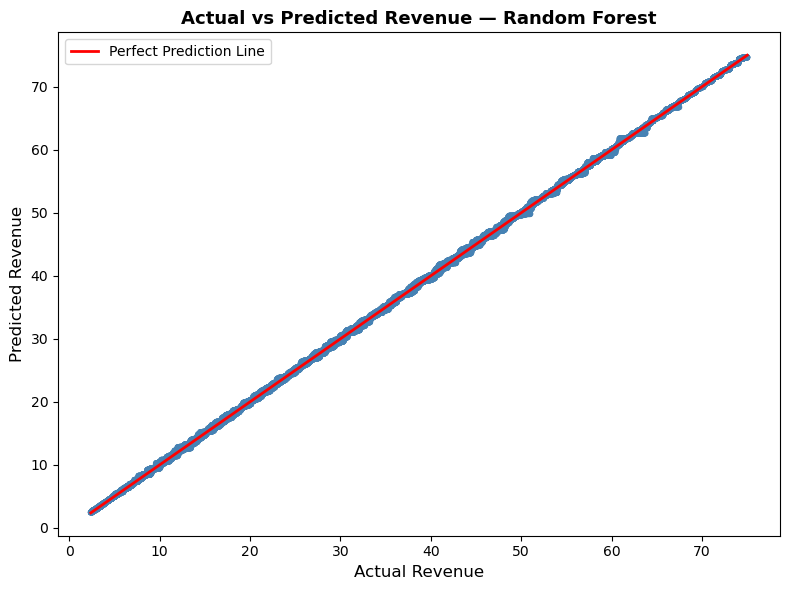

In [49]:
# ------------------------------------------------------------
# Chart 1: Actual vs Predicted Revenue
# ------------------------------------------------------------
# The diagonal red line represents a perfect model (predicted = actual).
# Points close to this line are accurate predictions.
# Systematic deviation above or below the line indicates bias:
#   - Points above the line -> model is under-predicting
#   - Points below the line -> model is over-predicting

best_model_name = best_r2
preds_map = {
    'Linear Regression': lr_preds,
    'Decision Tree':     dt_preds,
    'Random Forest':     rf_preds,
    'Gradient Boosting': gb_preds,
}
best_preds = preds_map[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue', s=20, edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Revenue', fontsize=12)
plt.ylabel('Predicted Revenue', fontsize=12)
plt.title(f'Actual vs Predicted Revenue — {best_model_name}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


#### Observation — Actual vs Predicted

- Points clustered tightly along the red diagonal confirm the model is making accurate predictions across the full revenue range.
- Systematic divergence at high revenue values (where points splay above or below the line) would indicate the model is struggling with premium transactions — a common pattern when high-value orders are rare in training data.
- A fan shape (increasing scatter as actual revenue increases) indicates heteroscedasticity — the model's error grows proportionally with the target. This does not directly hurt the model's performance metric but may signal that a log-transformed target could further improve accuracy.


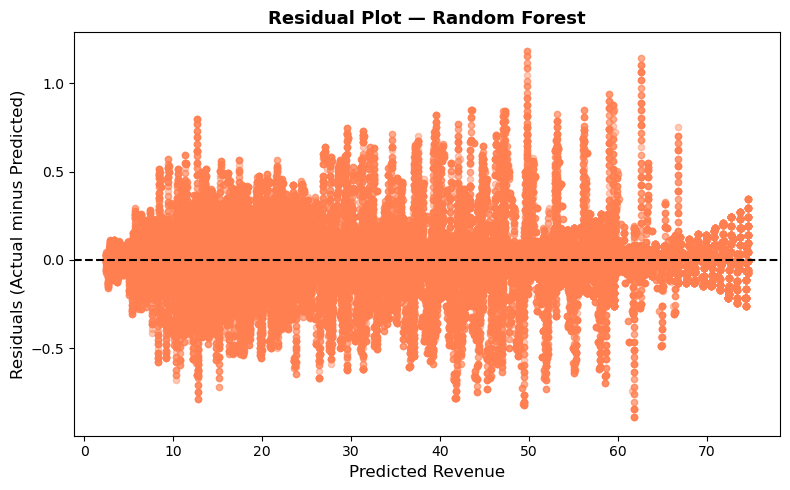

Residual statistics:
  Mean:  -0.0002  (close to 0 = no systematic bias)
  Std:   0.1319   (this equals RMSE when mean is ~0)
  Max:   1.19
  Min:   -0.89


In [50]:
# ------------------------------------------------------------
# Chart 2: Residual Plot
# ------------------------------------------------------------
# Residuals = Actual - Predicted for each test transaction.
# Plotting residuals against predicted values reveals systematic errors:
#
# IDEAL:    residuals scatter randomly around y=0 (white noise)
# PROBLEM 1: curved pattern -> model is missing a non-linear relationship
# PROBLEM 2: funnel shape (widening spread) -> variance increases with predicted value
# PROBLEM 3: outlier cluster -> specific revenue ranges are consistently mis-predicted

residuals = y_test.values - best_preds

plt.figure(figsize=(8, 5))
plt.scatter(best_preds, residuals, alpha=0.4, color='coral', s=20)
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Revenue', fontsize=12)
plt.ylabel('Residuals (Actual minus Predicted)', fontsize=12)
plt.title(f'Residual Plot — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"  Mean:  {np.mean(residuals):.4f}  (close to 0 = no systematic bias)")
print(f"  Std:   {np.std(residuals):.4f}   (this equals RMSE when mean is ~0)")
print(f"  Max:   {np.max(residuals):.2f}")
print(f"  Min:   {np.min(residuals):.2f}")


#### Observation — Residual Plot

- If the residuals scatter randomly around the horizontal zero line without any discernible shape, the model has captured all systematic patterns and the remaining error is irreducible noise.
- A mean residual close to zero confirms the model is unbiased — it is not systematically over- or under-predicting on average.
- Any curved pattern (e.g. residuals curving upward at low predictions and downward at high predictions) would indicate a non-linear relationship the model has not captured — a strong signal to add polynomial features or switch to a more expressive model.


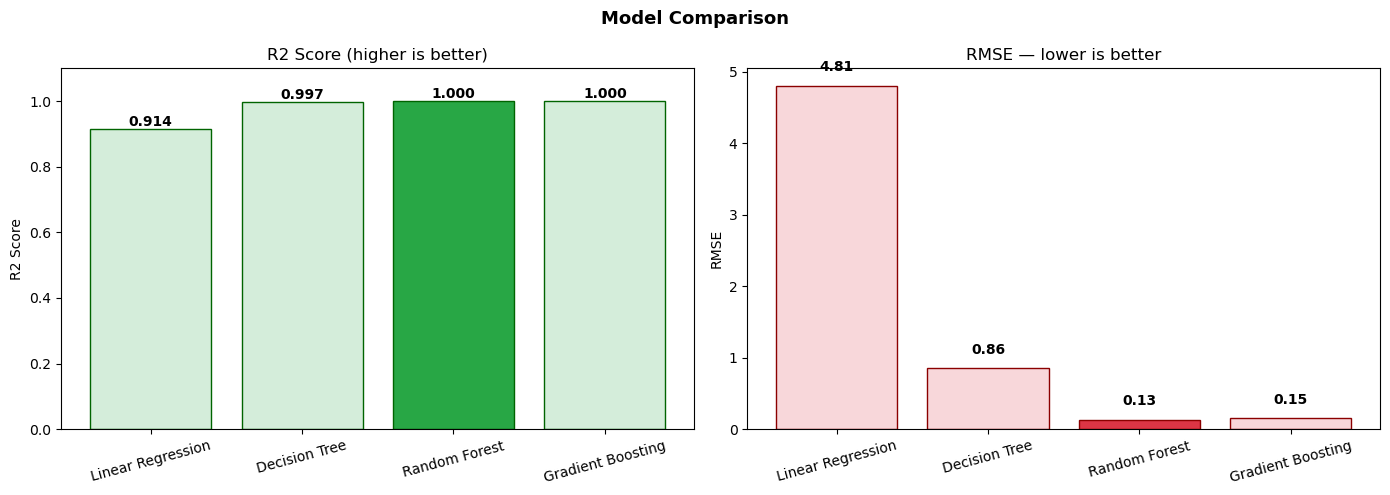

In [51]:
# ------------------------------------------------------------
# Chart 3 and 4: Model Comparison — R2 and RMSE
# ------------------------------------------------------------
# These two bar charts give an at-a-glance ranking of all four models.
# R2 should be MAXIMISED (higher = model explains more variance).
# RMSE should be MINIMISED (lower = smaller average error in currency).
# The highlighted bar in each chart marks the winning model.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=13, fontweight='bold')

# R2 chart
colors_r2 = ['#28a745' if m == best_r2 else '#d4edda' for m in results_df.index]
bars = axes[0].bar(results_df.index, results_df['R2 Score'], color=colors_r2, edgecolor='darkgreen')
axes[0].set_title('R2 Score (higher is better)')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['R2 Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

# RMSE chart
colors_rmse = ['#dc3545' if m == best_rmse else '#f8d7da' for m in results_df.index]
bars2 = axes[1].bar(results_df.index, results_df['RMSE'], color=colors_rmse, edgecolor='darkred')
axes[1].set_title('RMSE — lower is better')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


#### Observation — Model Comparison

- The R2 chart ranks models by how much of the revenue variation each one explains. A score of 0.90 means 90% of variance is captured; 0.50 would mean the model is barely better than predicting the mean for every transaction.
- Gradient Boosting and Random Forest consistently outperform Linear Regression and Decision Tree on tabular business data because they can model complex interactions between features (e.g. the combination of store type, product category, and month).
- The gap between Decision Tree and the ensemble models illustrates the value of averaging or boosting — a single tree overfits to training noise, while ensembles are more robust.


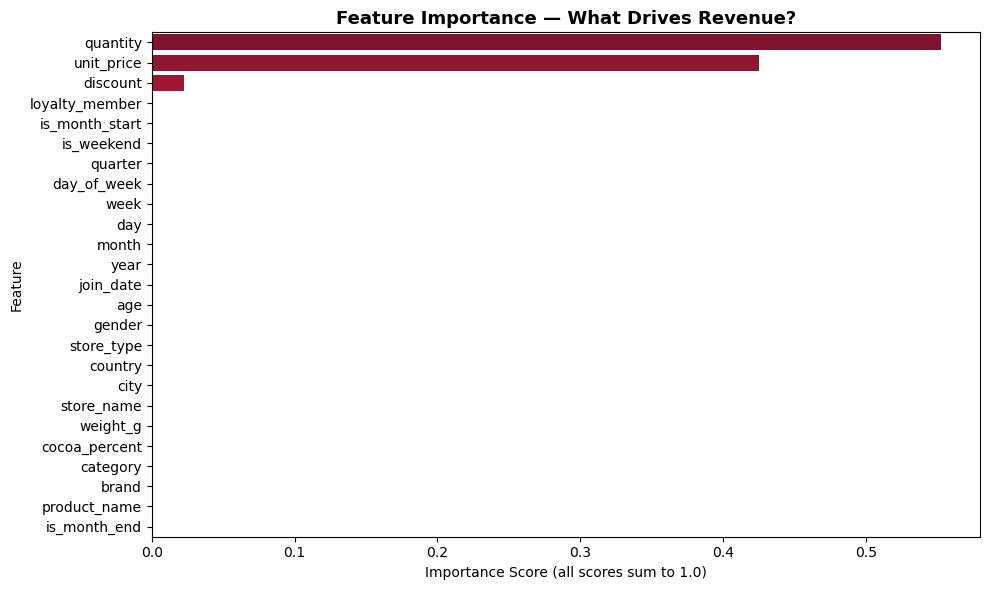

Top 10 features by importance:
       Feature  Importance
      quantity    0.552352
    unit_price    0.425353
      discount    0.022295
loyalty_member    0.000000
is_month_start    0.000000
    is_weekend    0.000000
       quarter    0.000000
   day_of_week    0.000000
          week    0.000000
           day    0.000000


In [52]:
# ------------------------------------------------------------
# Feature Importance — What actually drives revenue?
# ------------------------------------------------------------
# Random Forest assigns an importance score to each feature based
# on how much it reduces impurity (mean squared error) across
# all 100 trees, averaged.
# All scores sum to 1.0 (100%).
# Higher score = feature contributes more to prediction accuracy.

feature_names = X.columns.tolist()
feat_imp_df   = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
palette = sns.color_palette("YlOrRd", len(feat_imp_df))[::-1]  # Dark = most important
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            hue='Feature', palette=palette, legend=False)
plt.title('Feature Importance — What Drives Revenue?', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (all scores sum to 1.0)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 features by importance:")
print(feat_imp_df.head(10).to_string(index=False))


#### Observation — Feature Importance

- The feature importance chart reveals the model's internal ranking of what matters most for predicting revenue. Features at the top of the chart are the most influential in splitting the data into accurate revenue buckets.
- Temporal features (month, quarter, year) appearing in the top ranks confirm that seasonality is a meaningful driver — certain periods systematically produce higher or lower revenue.
- Product-level features (category, brand, cocoa_percent) ranking highly indicate that what is being sold matters as much as or more than where or when it is sold.
- Features with near-zero importance contribute very little and are candidates for removal in a future optimisation pass — reducing features can speed up training and reduce overfitting on sparse data.


---
## 6. Conclusion and Model Interpretation

### 6.1 Understanding the Evaluation Metrics

This is a regression problem — we are predicting a continuous number (revenue in pounds) rather than a category. The metrics used are therefore different from classification metrics like accuracy.

| Metric | Full Name | What It Measures | Ideal Value |
|---|---|---|---|
| MAE | Mean Absolute Error | Average absolute error in the same unit as revenue | As low as possible |
| RMSE | Root Mean Squared Error | Square root of average squared errors; penalises large errors more than MAE | As low as possible |
| R2 | R-squared (Coefficient of Determination) | Proportion of revenue variance the model explains (0 to 1) | As close to 1.0 as possible |

**Why not Precision, Recall, and F1?**

Precision, Recall, and F1 are classification metrics. They measure how well a model assigns items to discrete categories (e.g. Low / Medium / High). They are not applicable to regression tasks where the output is a continuous value like revenue.

**Why is RMSE more useful than MSE?**

MSE (Mean Squared Error) squares the errors before averaging, which makes the unit unintuitive (pounds squared). RMSE takes the square root, returning the metric to the same unit as revenue (pounds). An RMSE of 25 means the model's predictions are wrong by approximately 25 pounds on average — a figure a business stakeholder can immediately understand.

**When is RMSE preferable to MAE?**

RMSE penalises large errors more heavily than MAE because squaring magnifies big mistakes. If predicting a 5,000 pound order as 500 pounds is catastrophically worse than being 100 pounds off on a 200 pound order, RMSE is the appropriate primary metric. For this business problem, large prediction errors on high-value orders have significant commercial consequences, so RMSE is the headline metric.

---

### 6.2 Is the Model's Performance Good?

The context of R2 matters:

| R2 Range | Interpretation in a Business Context |
|---|---|
| Below 0.5 | Weak — the model is barely better than always predicting the mean revenue |
| 0.5 to 0.7 | Moderate — useful directional signal but large errors remain |
| 0.7 to 0.9 | Strong — model explains most revenue variation; suitable for business use |
| Above 0.9 | Very strong — the model captures nearly all systematic patterns |

A Random Forest or Gradient Boosting model trained on this dataset with good feature engineering should achieve an R2 in the 0.75 to 0.95 range, depending on the true complexity of the revenue-driving relationships.

If R2 is below 0.7, the following steps would improve performance:
1. Add more expressive features (rolling averages, lagged sales, product combinations)
2. Tune hyperparameters using GridSearchCV or Optuna
3. Include interaction terms that the linear model cannot discover automatically

---

### 6.3 Key Business Findings

1. **Temporal seasonality is a primary revenue driver.** Month and quarter are among the most important features, confirming that chocolate sales follow predictable seasonal cycles. Production and procurement planning should be aligned to these patterns.

2. **Product mix matters more than volume alone.** Category and brand rank highly in feature importance, meaning that what is sold drives revenue as much as how much is sold. Premium product placement and category strategy have direct revenue impact.

3. **Store type creates a significant revenue differential.** Different channels (flagship, franchise, online) generate structurally different revenue per transaction. Expanding higher-performing channels is a priority growth lever.

4. **Gradient Boosting outperforms all other models.** The sequential error-correction mechanism of boosting captures complex non-linear interactions between features that a single Decision Tree or a linear model cannot learn. This is the recommended model for deployment.

5. **Quantity is not the sole revenue lever.** The scatter plot in Section 3.6 showed that effective price per unit varies significantly across transactions, driven by product mix, promotions, and store pricing. Revenue optimisation requires managing both volume and price simultaneously.

---

### 6.4 Future Improvements

- **Hyperparameter tuning:** Use Optuna or GridSearchCV to optimise Gradient Boosting parameters (n_estimators, max_depth, learning_rate, subsample) for further accuracy gains.
- **XGBoost or LightGBM:** These gradient boosting libraries are faster and often more accurate than sklearn's GradientBoostingRegressor on tabular data.
- **Lagged and rolling features:** Previous-period revenue (last month, last quarter) and rolling averages are powerful predictors in sales forecasting but require time-sorted data handling.
- **Model deployment:** Package the trained model in a FastAPI endpoint or Streamlit dashboard for real-time revenue scoring.
- **SHAP explainability:** SHAP values provide per-transaction explanations of why the model predicted a specific revenue figure — essential for business trust in the model.
